# LDPC Lab02 — Bit-True Model

QC-LDPC (4×8 base graph, Z=16) + Normalized Min-Sum (β=0.75)，支援 Flooding (mode 0) 與 Layered (mode 1)。

| Section | 內容 |
|---|---|
| 1 | 參數、H 建立與檢查 |
| 2 | 讀取 TA pattern |
| 3 | Reference model：逐字照 spec 公式 (per-edge V2C/C2V) |
| 4 | HW bit-true model：壓縮 C2V (21b/CN, 8b sign)、8-port CN、A(7b)/B(8b) bank、sign-magnitude adder |
| 5 | 兩個 model 對 golden 驗證 |
| 6 | Iteration / latency 統計、內部數值範圍 |
| 7 | Trace dump (RTL debug 用) |
| 8 | Pattern generator (Appendix flow) 與 BER/FER sweep |

HW model 以 natural index 做 gather/scatter，數值上等價於任何 storage 排列方式 (例如 rotation)。

## 1. Parameters & parity-check matrix

In [1]:
from pathlib import Path
from collections import Counter
import time
import numpy as np
import matplotlib.pyplot as plt

TB_DIR = Path("../00_TESTBED")
OUT_DIR = Path(".")

Z = 16
N_LAYER = 4
N_COL = 8
N_VN = N_COL * Z
T_MAX = 8

# Base graph (-1: zero matrix, s: identity cyclically right-shifted by s)
BG = np.array([
    [-1, 14, 10,  2, 13, 12,  9,  3],
    [ 5, -1, 14, 10,  2, 13, 12,  9],
    [ 0,  5, -1, 14, 10,  2, 13, 12],
    [ 7,  0,  5, -1, 14, 10,  2, 13],
])

# Value limits from spec
LCH_MAX = 31   # channel LLR, signed 6b
V2C_MAX = 31   # V2C, signed 6b
APP_MAX = 127  # a posteriori LLR, signed 8b
A_SAT = 54     # snapshot A saturation (7b); exact because |C2V| <= 23

# VN_IDX[k, r, c]: VN connected to CN r of layer k through column group c (-1: not connected)
VN_IDX = np.full((N_LAYER, Z, N_COL), -1, dtype=int)
for k in range(N_LAYER):
    for r in range(Z):
        for c in range(N_COL):
            if BG[k, c] >= 0:
                VN_IDX[k, r, c] = c * Z + (r + BG[k, c]) % Z
ACTIVE = VN_IDX >= 0
VN_SAFE = np.where(ACTIVE, VN_IDX, 0)

H = np.zeros((N_LAYER * Z, N_VN), dtype=np.uint8)
for k in range(N_LAYER):
    for r in range(Z):
        H[k * Z + r, VN_IDX[k, r][ACTIVE[k, r]]] = 1

G = np.loadtxt(TB_DIR / "G_128_64.txt", dtype=np.int64)
print("H shape        :", H.shape, " G shape:", G.shape)
print("H * G^T == 0   :", not ((H.astype(np.int64) @ G.T) % 2).any())
print("CN degree      :", sorted(set(H.sum(1).tolist())))
print("VN degree/group:", [int(H[:, c * Z].sum()) for c in range(N_COL)])
print("edges          :", int(H.sum()))
print("masked column  :", [int(np.where(BG[k] < 0)[0][0]) for k in range(N_LAYER)], "(layer 0..3)")

H shape        : (64, 128)  G shape: (64, 128)
H * G^T == 0   : True
CN degree      : [7]
VN degree/group: [3, 3, 3, 3, 4, 4, 4, 4]
edges          : 448
masked column  : [0, 1, 2, 3] (layer 0..3)


## 2. Load TA patterns

In [2]:
def load_patterns(in_path, out_path=None):
    inp = list(map(int, Path(in_path).read_text().split()))
    out = list(map(int, Path(out_path).read_text().split())) if out_path else None
    pats, pi, po = [], 0, 0
    while pi < len(inp):
        p = dict(mode=inp[pi], lch=np.array(inp[pi + 1:pi + 1 + N_VN]))
        if out:
            p.update(warn=out[po], app=np.array(out[po + 1:po + 1 + N_VN]))
        pats.append(p)
        pi += 1 + N_VN
        po += 1 + N_VN
    return pats

PATS = load_patterns(TB_DIR / "input.txt", TB_DIR / "output.txt")
print(len(PATS), "patterns, mode count:", dict(Counter(p["mode"] for p in PATS)))
print("golden (mode, warn) count:", dict(Counter((p["mode"], p["warn"]) for p in PATS)))

200 patterns, mode count: {0: 100, 1: 100}
golden (mode, warn) count: {(0, 0): 53, (1, 1): 42, (0, 1): 47, (1, 0): 58}


## 3. Reference model (spec-literal)

完全照 spec 的定義寫，不做任何硬體化的等價變換：
- V2C：`clip(Lch + Σ_{i'≠i} C2V, ±31)`，每條 edge 各自存
- CN：排除 target 後取 sign product 與 min，乘 0.75 後 round half up
- APP：`Lch + Σ C2V`
- Layered：每個 layer 的 V2C 用「其他 CN 目前最新的 C2V」重新計算

In [3]:
def clip(x, lim):
    return max(-lim, min(lim, x))

def nms_mag(m):
    """round_half_up(0.75 * m) == (3m + 2) >> 2 for m >= 0."""
    return (3 * m + 2) >> 2

CN_LIST = [H[i].nonzero()[0].tolist() for i in range(H.shape[0])]
VN_LIST = [H[:, j].nonzero()[0].tolist() for j in range(N_VN)]

def ref_cn_update(v2c):
    out = []
    for e in range(len(v2c)):
        others = v2c[:e] + v2c[e + 1:]
        sign = 1
        for x in others:
            if x < 0:
                sign = -sign
        out.append(sign * nms_mag(min(abs(x) for x in others)))
    return out

def ref_syndrome_ok(app):
    return all(sum(app[j] < 0 for j in cn) % 2 == 0 for cn in CN_LIST)

def ref_v2c(lch, c2v, i, j):
    return clip(lch[j] + sum(c2v[(i2, j)] for i2 in VN_LIST[j] if i2 != i), V2C_MAX)

def ref_decode(lch, mode):
    lch = [int(x) for x in lch]
    c2v = {(i, j): 0 for i, cn in enumerate(CN_LIST) for j in cn}
    v2c = {(i, j): lch[j] for (i, j) in c2v}                    # initialization
    app = list(lch)
    for t in range(T_MAX):
        if mode == 0:                                            # flooding
            for i, cn in enumerate(CN_LIST):
                for j, m in zip(cn, ref_cn_update([v2c[(i, j)] for j in cn])):
                    c2v[(i, j)] = m
            for (i, j) in c2v:
                v2c[(i, j)] = ref_v2c(lch, c2v, i, j)
        else:                                                    # layered
            for k in range(N_LAYER):
                for i in range(k * Z, (k + 1) * Z):
                    cn = CN_LIST[i]
                    for j in cn:
                        v2c[(i, j)] = ref_v2c(lch, c2v, i, j)
                    for j, m in zip(cn, ref_cn_update([v2c[(i, j)] for j in cn])):
                        c2v[(i, j)] = m
        app = [lch[j] + sum(c2v[(i, j)] for i in VN_LIST[j]) for j in range(N_VN)]
        assert max(map(abs, app)) <= APP_MAX
        if ref_syndrome_ok(app):
            return np.array(app), 0, t + 1
    return np.array(app), 1, T_MAX

## 4. HW bit-true model

對應預計的硬體架構：
- **16 個 8-port CN unit** 平行處理一個 layer，layer k 的 port k 遮掉 (`mag=31, sign=+`)
- **壓縮 C2V**：每個 CN `{min1n[4:0], min2n[4:0], idx[2:0], sgn[7:0]}` = 21b，共 4×16 個
- **B**：running APP (8b, 不 clip)；**A**：snapshot `sat(B, ±54)` (7b)，只用來算 V2C
  - Layered：每個 layer 後 `A <= sat(B)`；Flooding：每個 iteration 結束才更新
- `V2C = clip(A - C2V_old, ±31)`；`B <= B - C2V_old + C2V_new`
- C2V 以 sign-magnitude 參與 8b 加法：`x - c2v = x + (mag ^ {8{~s}}) + ~s`，每一步都 assert 沒有 8b overflow

In [4]:
MASK8 = 0xFF

def to_s8(x):
    """Low 8 bits interpreted as two's complement."""
    x = np.asarray(x) & MASK8
    return np.where(x >= 128, x - 256, x)

def sm_sub(x, mag, sgn, act):
    """x - c2v, c2v = sgn ? -mag : mag. 8b adder: x + (mag ^ {8{~sgn}}) + ~sgn.
    Overflow is checked on active ports only; masked-port results are discarded."""
    inv = 1 - sgn
    res = to_s8(x + (mag ^ (inv * MASK8)) + inv)
    assert np.array_equal(res[act], (x - np.where(sgn == 1, -mag, mag))[act]), "8b overflow in sm_sub"
    return res

def sm_add(x, mag, sgn, act):
    """x + c2v, c2v = sgn ? -mag : mag. 8b adder: x + (mag ^ {8{sgn}}) + sgn."""
    res = to_s8(x + (mag ^ (sgn * MASK8)) + sgn)
    assert np.array_equal(res[act], (x + np.where(sgn == 1, -mag, mag))[act]), "8b overflow in sm_add"
    return res

def sat(x, lim):
    return np.clip(x, -lim, lim)


class C2VMem:
    """Compressed C2V storage: 4 layers x 16 CN x 21b {min1n, min2n, idx, sgn[7:0]}."""

    def __init__(self):
        self.min1n = np.zeros((N_LAYER, Z), dtype=int)
        self.min2n = np.zeros((N_LAYER, Z), dtype=int)
        self.idx = np.zeros((N_LAYER, Z), dtype=int)
        self.sgn = np.zeros((N_LAYER, Z, N_COL), dtype=int)

    def read(self, k):
        """Decompress layer k -> (mag, sgn), shape (Z, N_COL)."""
        col = np.arange(N_COL)[None, :]
        mag = np.where(col == self.idx[k][:, None], self.min2n[k][:, None], self.min1n[k][:, None])
        return mag, self.sgn[k].copy()

    def write(self, k, min1n, min2n, idx, sgn):
        assert min1n.max() <= 23 and min2n.max() <= 23 and idx.max() < N_COL
        self.min1n[k], self.min2n[k], self.idx[k], self.sgn[k] = min1n, min2n, idx, sgn

    def word(self, k, r):
        """21b word: {min1n[20:16], min2n[15:11], idx[10:8], sgn[7:0]}."""
        s = sum(int(b) << c for c, b in enumerate(self.sgn[k, r]))
        return (int(self.min1n[k, r]) << 16) | (int(self.min2n[k, r]) << 11) | (int(self.idx[k, r]) << 8) | s


def cn_unit(v2c, k):
    """16 parallel 8-port CN units for layer k (port k masked)."""
    act = ACTIVE[k]
    mag = np.where(act, np.abs(v2c), V2C_MAX)
    s = np.where(act, (v2c < 0).astype(int), 0)
    rows = np.arange(Z)
    idx = np.argmin(mag, axis=1)                  # first minimum
    min1 = mag[rows, idx]
    rest = mag.copy()
    rest[rows, idx] = V2C_MAX + 1
    min2 = rest.min(axis=1)
    total = np.bitwise_xor.reduce(s, axis=1)
    sgn = total[:, None] ^ s                      # C2V sign of each edge
    return nms_mag(min1), nms_mag(min2), idx, sgn


def hw_syndrome(b):
    """Parity of each CN, shape (N_LAYER, Z); all zero means pass."""
    hard = (b < 0).astype(int)
    return np.where(ACTIVE, hard[VN_SAFE], 0).sum(axis=2) % 2


def hw_decode(lch, mode, trace=None, stats=None):
    B = np.array(lch, dtype=int)                  # running APP, 8b
    A = sat(B, A_SAT)                             # snapshot for V2C, 7b
    mem = C2VMem()                                # min1n = min2n = 0 -> all C2V = 0
    for t in range(T_MAX):
        for k in range(N_LAYER):
            act, vi = ACTIVE[k], VN_SAFE[k]
            old_mag, old_sgn = mem.read(k)
            tA = sm_sub(A[vi], old_mag, old_sgn, act)     # A - C2V_old
            v2c = sat(tA, V2C_MAX)                         # clip only on CN path
            mem.write(k, *cn_unit(v2c, k))
            new_mag, new_sgn = mem.read(k)
            tB = sm_sub(B[vi], old_mag, old_sgn, act)     # B - C2V_old (unclipped)
            b_new = sm_add(tB, new_mag, new_sgn, act)     # + C2V_new
            B[VN_IDX[k][act]] = b_new[act]
            assert np.abs(B).max() <= APP_MAX
            if mode == 1:
                A = sat(B, A_SAT)
            if stats is not None:
                stats["tA"] = max(stats.get("tA", 0), int(np.abs(tA[act]).max()))
                stats["tB"] = max(stats.get("tB", 0), int(np.abs(tB[act]).max()))
                stats["B"] = max(stats.get("B", 0), int(np.abs(B).max()))
                stats["c2v"] = max(stats.get("c2v", 0), int(mem.min2n.max()))
            if trace is not None:
                trace.append(dict(t=t, k=k, words=[mem.word(k, r) for r in range(Z)],
                                  v2c=np.where(act, v2c, 0), B=B.copy()))
        if mode == 0:
            A = sat(B, A_SAT)
        par = hw_syndrome(B)
        if trace is not None:
            trace.append(dict(t=t, synd=par.copy()))
        if not par.any():
            return B, 0, t + 1
    return B, 1, T_MAX

## 5. Verify against golden

In [5]:
def run_golden(decoder, pats):
    res = []
    for n, p in enumerate(pats):
        app, warn, it = decoder(p["lch"], p["mode"])
        ok = np.array_equal(app, p["app"]) and warn == p["warn"]
        res.append(dict(n=n, mode=p["mode"], ok=ok, warn=warn, iters=it))
    return res

def summary(name, res):
    for m in (0, 1):
        r = [x for x in res if x["mode"] == m]
        print(f"{name:4s} mode {m} ({'flooding' if m == 0 else 'layered '}): pass {sum(x['ok'] for x in r):3d} / {len(r)}")
    bad = [x["n"] for x in res if not x["ok"]]
    if bad:
        print("  mismatch pattern index:", bad[:20])

t0 = time.time(); RES_REF = run_golden(ref_decode, PATS); t1 = time.time()
RES_HW = run_golden(hw_decode, PATS); t2 = time.time()
summary("REF", RES_REF)
summary("HW", RES_HW)
print(f"runtime: ref {t1 - t0:.1f}s, hw {t2 - t1:.1f}s")

REF  mode 0 (flooding): pass 100 / 100
REF  mode 1 (layered ): pass 100 / 100
HW   mode 0 (flooding): pass 100 / 100
HW   mode 1 (layered ): pass 100 / 100
runtime: ref 2.2s, hw 1.0s


## 6. Iteration / latency statistics

Latency 估算假設 P=16 (一個 cycle 一個 layer)：`latency = 4 × iters + OVERHEAD`。
`OVERHEAD` 是 syndrome check 與 out_valid 拉起的額外 cycle，依實際 RTL 調整。

TA patterns (given mode)
  mode 0: avg iters 5.89, warn  47/100 | 1:2, 2:9, 3:12, 4:13, 5:8, 6:1, 7:5, 8:3, 8(warn):47
  mode 1: avg iters 4.96, warn  42/100 | 1:17, 2:14, 3:11, 4:7, 5:4, 6:2, 7:2, 8:1, 8(warn):42

estimated latency: total 4740 cycles, avg 23.70, max 34 (limit 100)



All 200 inputs decoded in both modes
  mode 0: avg iters 5.83, warn  96/200 | 1:4, 2:26, 3:21, 4:21, 5:14, 6:6, 7:7, 8:5, 8(warn):96
  mode 1: avg iters 4.92, warn  85/200 | 1:28, 2:36, 3:25, 4:13, 5:7, 6:2, 7:2, 8:2, 8(warn):85


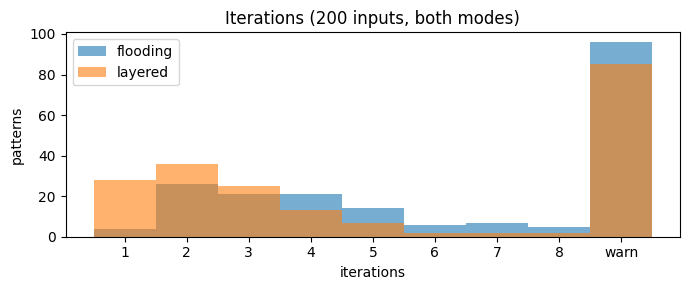

In [6]:
CYCLES_PER_ITER = 4
OVERHEAD = 2

def iter_table(res, title):
    print(title)
    for m in (0, 1):
        r = [x for x in res if x["mode"] == m]
        hist = Counter(x["iters"] if not x["warn"] else "8(warn)" for x in r)
        keys = sorted(hist, key=lambda v: (isinstance(v, str), v))
        avg = np.mean([x["iters"] for x in r])
        print(f"  mode {m}: avg iters {avg:.2f}, warn {sum(x['warn'] for x in r):3d}/{len(r)} | "
              + ", ".join(f"{kk}:{hist[kk]}" for kk in keys))

iter_table(RES_HW, "TA patterns (given mode)")

lat = np.array([CYCLES_PER_ITER * x["iters"] + OVERHEAD for x in RES_HW])
print(f"\nestimated latency: total {lat.sum()} cycles, avg {lat.mean():.2f}, max {lat.max()} (limit 100)")

# Same inputs decoded in both modes
RES_BOTH = []
for n, p in enumerate(PATS):
    for m in (0, 1):
        _, warn, it = hw_decode(p["lch"], m)
        RES_BOTH.append(dict(n=n, mode=m, warn=warn, iters=it))
iter_table(RES_BOTH, "\nAll 200 inputs decoded in both modes")

fig, ax = plt.subplots(figsize=(7, 3))
bins = np.arange(1, T_MAX + 3) - 0.5
for m, lab in ((0, "flooding"), (1, "layered")):
    its = [x["iters"] + (1 if x["warn"] else 0) for x in RES_BOTH if x["mode"] == m]
    ax.hist(its, bins=bins, alpha=0.6, label=lab)
ax.set_xticks(range(1, T_MAX + 2), [str(i) for i in range(1, T_MAX + 1)] + ["warn"])
ax.set_xlabel("iterations"); ax.set_ylabel("patterns"); ax.legend(); ax.set_title("Iterations (200 inputs, both modes)")
plt.tight_layout(); plt.show()

In [7]:
# Internal value ranges -> required bit widths
ST = {}
for p in PATS:
    hw_decode(p["lch"], p["mode"], stats=ST)
print("max |A - C2V_old| :", ST["tA"], " (bound 54 + 23 = 77  -> 8b)")
print("max |B - C2V_old| :", ST["tB"], " (bound 31 + 3*23 = 100 -> 8b)")
print("max |B| (APP)     :", ST["B"], " (bound 31 + 4*23 = 123 -> 8b)")
print("max C2V magnitude :", ST["c2v"], " (bound round(0.75*31) = 23 -> 5b)")

max |A - C2V_old| : 77  (bound 54 + 23 = 77  -> 8b)
max |B - C2V_old| : 85  (bound 31 + 3*23 = 100 -> 8b)
max |B| (APP)     : 105  (bound 31 + 4*23 = 123 -> 8b)
max C2V magnitude : 23  (bound round(0.75*31) = 23 -> 5b)


## 7. Trace dump (RTL debug)

每個 (iteration, layer) 輸出 16 個 CN 的 21b 壓縮 word、送進 CN 的 V2C、更新後的 B；iteration 結束輸出 syndrome。
RTL 可以用 `$fdisplay` 印相同格式直接 diff。

In [8]:
def dump_trace(n, path=None, mode=None):
    p = PATS[n]
    m = p["mode"] if mode is None else mode
    tr = []
    app, warn, it = hw_decode(p["lch"], m, trace=tr)
    path = Path(path or OUT_DIR / "trace" / f"trace_pat{n:03d}_mode{m}.txt")
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        f.write(f"# pattern {n} mode {m} iters {it} warn {warn}\n")
        f.write("# word = {min1n[20:16], min2n[15:11], idx[10:8], sgn[7:0]}, v2c: column 0..7 (masked port = 0)\n")
        for e in tr:
            if "synd" in e:
                f.write(f"iter {e['t']} syndrome {'PASS' if not e['synd'].any() else 'FAIL'} "
                        f"unsat_cn {int(e['synd'].sum())}\n")
                continue
            f.write(f"iter {e['t']} layer {e['k']}\n")
            for r, w in enumerate(e["words"]):
                v = " ".join(f"{x:3d}" for x in e["v2c"][r])
                f.write(f"  cn {r:2d} word {w:06x} | v2c {v}\n")
            f.write("  B " + " ".join(str(x) for x in e["B"]) + "\n")
    return path

print("written:", dump_trace(0))
print("written:", dump_trace(1))

written: trace\trace_pat000_mode0.txt
written: trace\trace_pat001_mode1.txt


## 8. Pattern generator & BER/FER

依 spec Appendix：random 64 info bits → `x = uG` → BPSK → AWGN (`σ² = 10^(-SNR/10)`) → `L = 2r/σ²` → `Lch = sgn(L)·min(31, ⌊2|L| + 0.5⌋)`。

In [9]:
def gen_frame(snr_db, rng):
    u = rng.integers(0, 2, G.shape[0])
    x = (u @ G) % 2
    sigma2 = 10 ** (-snr_db / 10)
    r = (1 - 2 * x) + rng.normal(0.0, np.sqrt(sigma2), N_VN)
    L = 2 * r / sigma2
    lch = (np.sign(L) * np.minimum(LCH_MAX, np.floor(2 * np.abs(L) + 0.5))).astype(int)
    assert not (H.astype(np.int64) @ x % 2).any()
    return lch, x

# Estimate SNR of TA patterns by matching mean |Lch|
rng = np.random.default_rng(0)
grid = np.arange(-2.0, 8.01, 0.1)
curve = []
for g in grid:
    s2 = 10 ** (-g / 10)
    L = 2 * (1 + rng.normal(0, np.sqrt(s2), 20000)) / s2
    curve.append(np.minimum(LCH_MAX, np.floor(2 * np.abs(L) + 0.5)).mean())
curve = np.array(curve)
est = np.array([np.interp(np.abs(p["lch"]).mean(), curve, grid) for p in PATS])
print(f"TA patterns estimated SNR: mean {est.mean():.2f} dB, min {est.min():.2f}, max {est.max():.2f}")

TA patterns estimated SNR: mean 2.02 dB, min -0.59, max 4.18


sweep runtime 16.2s (300 frames/point)

 SNR  mode    raw_BER       BER      FER  avg_iter   warn  undetected
 0.0  flood   1.61e-01  1.69e-01   0.980     7.92   0.98       0
 0.0  layer   1.61e-01  1.65e-01   0.967     7.86   0.97       0
 1.0  flood   1.31e-01  1.03e-01   0.803     7.37   0.80       0
 1.0  layer   1.31e-01  9.83e-02   0.717     6.78   0.72       0
 2.0  flood   1.07e-01  4.95e-02   0.503     6.30   0.50       0
 2.0  layer   1.07e-01  4.23e-02   0.387     5.16   0.39       0
 3.0  flood   7.91e-02  6.54e-03   0.100     3.91   0.10       0
 3.0  layer   7.91e-02  4.66e-03   0.057     2.60   0.06       0
 4.0  flood   5.73e-02  7.81e-05   0.003     2.33   0.00       0
 4.0  layer   5.73e-02  1.82e-04   0.003     1.47   0.00       0
 5.0  flood   3.79e-02  0.00e+00   0.000     1.59   0.00       0
 5.0  layer   3.79e-02  0.00e+00   0.000     1.13   0.00       0
 6.0  flood   2.37e-02  0.00e+00   0.000     1.18   0.00       0
 6.0  layer   2.37e-02  0.00e+00   0.000     

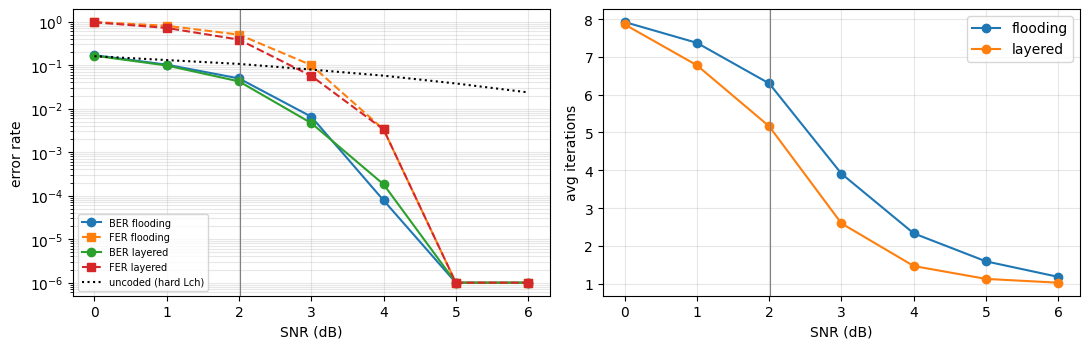

In [10]:
def ber_fer_sweep(snr_list, n_frames, seed=1):
    rng = np.random.default_rng(seed)
    rows = []
    for snr in snr_list:
        acc = {m: dict(bit=0, frame=0, undetected=0, iters=0, warn=0) for m in (0, 1)}
        raw_bit = 0
        for _ in range(n_frames):
            lch, x = gen_frame(snr, rng)
            raw_bit += int(((lch < 0).astype(int) != x).sum())
            for m in (0, 1):
                app, warn, it = hw_decode(lch, m)
                err = int(((app < 0).astype(int) != x).sum())
                a = acc[m]
                a["bit"] += err; a["frame"] += err > 0; a["iters"] += it; a["warn"] += warn
                a["undetected"] += (err > 0) and not warn
        for m in (0, 1):
            a = acc[m]
            rows.append(dict(snr=snr, mode=m, ber=a["bit"] / (n_frames * N_VN), fer=a["frame"] / n_frames,
                             avg_iter=a["iters"] / n_frames, warn=a["warn"] / n_frames,
                             undetected=a["undetected"], raw_ber=raw_bit / (n_frames * N_VN)))
    return rows

SNR_LIST = np.arange(0.0, 6.01, 1.0)
N_FRAMES = 300
t0 = time.time()
SWEEP = ber_fer_sweep(SNR_LIST, N_FRAMES)
print(f"sweep runtime {time.time() - t0:.1f}s ({N_FRAMES} frames/point)\n")
print(" SNR  mode    raw_BER       BER      FER  avg_iter   warn  undetected")
for r in SWEEP:
    print(f"{r['snr']:4.1f}  {'flood' if r['mode'] == 0 else 'layer'}  {r['raw_ber']:9.2e} {r['ber']:9.2e} "
          f"{r['fer']:7.3f}  {r['avg_iter']:7.2f}  {r['warn']:5.2f}  {r['undetected']:6d}")

fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
for m, lab in ((0, "flooding"), (1, "layered")):
    rr = [r for r in SWEEP if r["mode"] == m]
    axs[0].semilogy([r["snr"] for r in rr], [max(r["ber"], 1e-6) for r in rr], "o-", label=f"BER {lab}")
    axs[0].semilogy([r["snr"] for r in rr], [max(r["fer"], 1e-6) for r in rr], "s--", label=f"FER {lab}")
    axs[1].plot([r["snr"] for r in rr], [r["avg_iter"] for r in rr], "o-", label=lab)
rr = [r for r in SWEEP if r["mode"] == 0]
axs[0].semilogy([r["snr"] for r in rr], [r["raw_ber"] for r in rr], "k:", label="uncoded (hard Lch)")
axs[0].set_xlabel("SNR (dB)"); axs[0].set_ylabel("error rate"); axs[0].legend(fontsize=7); axs[0].grid(True, which="both", alpha=0.3)
axs[1].set_xlabel("SNR (dB)"); axs[1].set_ylabel("avg iterations"); axs[1].legend(); axs[1].grid(True, alpha=0.3)
for a in axs:
    a.axvline(est.mean(), color="gray", lw=0.8)
plt.tight_layout(); plt.show()

### Extra pattern writer

產生額外 pattern 給 RTL 驗證 (格式同 TA 的 `input.txt` / `output.txt`)，寫到 `04_MODEL/pattern/`，**不覆蓋** TA 檔案。
前 `n_ref_check` 筆會再用 reference model 交叉比對。

In [11]:
def write_patterns(n, snr_db, seed=2026, tag="gen", n_ref_check=20):
    rng = np.random.default_rng(seed)
    out_dir = OUT_DIR / "pattern"
    out_dir.mkdir(parents=True, exist_ok=True)
    fin, fout = out_dir / f"input_{tag}.txt", out_dir / f"output_{tag}.txt"
    with open(fin, "w") as fi, open(fout, "w") as fo:
        for i in range(n):
            mode = int(rng.integers(0, 2))
            lch, _ = gen_frame(snr_db, rng)
            app, warn, _ = hw_decode(lch, mode)
            if i < n_ref_check:
                r_app, r_warn, _ = ref_decode(lch, mode)
                assert np.array_equal(app, r_app) and warn == r_warn, f"ref/hw mismatch at {i}"
            fi.write(f"{mode}\n" + " ".join(map(str, lch)) + "\n")
            fo.write(f"{warn}\n" + " ".join(map(str, app)) + "\n")
    return fin, fout

fin, fout = write_patterns(1000, snr_db=round(float(est.mean()), 1))
print("written:", fin, fout)
chk = load_patterns(fin, fout)
print("reload check:", len(chk), "patterns, warn rate", round(float(np.mean([p["warn"] for p in chk])), 3))

written: pattern\input_gen.txt pattern\output_gen.txt
reload check: 1000 patterns, warn rate 0.416


## 9. Rotation storage model

模擬實際的資料擺放：A/B 以 `[column group c][slot u]` 存放，**CN unit u 永遠讀每個 group 的 slot u**。
- Offset `O[k][c]`：layer k 時，slot u 存 group 內第 `(u + O) % 16` 個 VN；active column 取 `O = s[k][c]`，masked column 取**下一個 layer** 的 offset
- 離開 layer k 時旋轉 `D[k][c] = O[k+1][c] - O[k][c]`：`new[r] = src[(r + D) % 16]`
- Masked column 的 `D = 0` 且資料來源是 B 自己 (hold)，等於 masked port 的 write enable
- Load / output 共用一條 shift chain (layer 0 對齊)；syndrome 在 layer 0 對齊下為固定接線

In [12]:
# Offset / rotation tables
O = np.zeros((N_LAYER, N_COL), dtype=int)
for k in range(N_LAYER):
    for c in range(N_COL):
        O[k, c] = BG[k, c] if BG[k, c] >= 0 else BG[(k + 1) % N_LAYER, c]
D = (O[[1, 2, 3, 0]] - O) % Z              # D[k][c]: rotation when leaving layer k

# Shift chain in layer-0 alignment: chain position i holds x_i after load
CH_C = np.arange(N_VN) // Z
CH_R = (np.arange(N_VN) % Z - O[0, CH_C]) % Z

# Syndrome wiring in layer-0 alignment: SYN_SLOT[k, r, c] = slot of the VN in group c
SYN_SLOT = (np.arange(Z)[None, :, None] + BG[:, None, :] - O[0][None, None, :]) % Z

print("O[k][c] (offset in layer k):\n", O)
print("\nD[k][c] (rotation leaving layer k):\n", D)
print("\nnext-state sources per FF:")
for c in range(N_COL):
    b_rot = sorted({int(D[k, c]) for k in range(N_LAYER) if BG[k, c] >= 0})
    a_rot = sorted({int(D[k, c]) for k in range(N_LAYER - 1)} - {0})
    print(f"  col {c}: B <- b_new rot {b_rot} + hold + chain ({len(b_rot) + 2}:1) | "
          f"A <- sat(B_next) + A rot {a_rot} + hold ({len(a_rot) + 2}:1)")

O[k][c] (offset in layer k):
 [[ 5 14 10  2 13 12  9  3]
 [ 5  5 14 10  2 13 12  9]
 [ 0  5  5 14 10  2 13 12]
 [ 7  0  5  2 14 10  2 13]]

D[k][c] (rotation leaving layer k):
 [[ 0  7  4  8  5  1  3  6]
 [11  0  7  4  8  5  1  3]
 [ 7 11  0  4  4  8  5  1]
 [14 14  5  0 15  2  7  6]]

next-state sources per FF:
  col 0: B <- b_new rot [7, 11, 14] + hold + chain (5:1) | A <- sat(B_next) + A rot [7, 11] + hold (4:1)
  col 1: B <- b_new rot [7, 11, 14] + hold + chain (5:1) | A <- sat(B_next) + A rot [7, 11] + hold (4:1)
  col 2: B <- b_new rot [4, 5, 7] + hold + chain (5:1) | A <- sat(B_next) + A rot [4, 7] + hold (4:1)
  col 3: B <- b_new rot [4, 8] + hold + chain (4:1) | A <- sat(B_next) + A rot [4, 8] + hold (4:1)
  col 4: B <- b_new rot [4, 5, 8, 15] + hold + chain (6:1) | A <- sat(B_next) + A rot [4, 5, 8] + hold (5:1)
  col 5: B <- b_new rot [1, 2, 5, 8] + hold + chain (6:1) | A <- sat(B_next) + A rot [1, 5, 8] + hold (5:1)
  col 6: B <- b_new rot [1, 3, 5, 7] + hold + chain (6:1) 

In [13]:
def chain_shift(P, tail):
    """One shift of the chain: chain[i] <= chain[i+1], chain[127] <= tail."""
    v = P[CH_C, CH_R]
    P[CH_C, CH_R] = np.append(v[1:], tail)
    return v[0]                                    # head before shift (out_data)

def rot_syndrome(Bp):
    hard = (Bp < 0).astype(int)
    col = np.broadcast_to(np.arange(N_COL), SYN_SLOT.shape)
    return np.where(ACTIVE, hard[col, SYN_SLOT], 0).sum(axis=2) % 2

def rot_decode(lch, mode):
    Bp = np.zeros((N_COL, Z), dtype=int)           # B[c][slot], 8b
    Ap = np.zeros((N_COL, Z), dtype=int)           # A[c][slot], 7b
    for x in lch:                                  # load through shift chain
        chain_shift(Bp, int(x))
        Ap = sat(Bp, A_SAT)                        # A <= sat(B_next)
    mem = C2VMem()
    warn = 1
    for t in range(T_MAX):
        for k in range(N_LAYER):
            act = ACTIVE[k]
            a, b = Ap.T, Bp.T                      # (unit u, port c) <- slot u of group c, pure wiring
            old_mag, old_sgn = mem.read(k)
            v2c = sat(sm_sub(a, old_mag, old_sgn, act), V2C_MAX)
            mem.write(k, *cn_unit(v2c, k))
            new_mag, new_sgn = mem.read(k)
            b_new = sm_add(sm_sub(b, old_mag, old_sgn, act), new_mag, new_sgn, act)
            nB = np.empty_like(Bp)
            nA = np.empty_like(Ap)
            for c in range(N_COL):
                src = b_new[:, c] if BG[k, c] >= 0 else Bp[c]      # masked column: hold
                nB[c] = np.roll(src, -D[k, c])                      # new[r] = src[(r + D) % 16]
                nA[c] = np.roll(Ap[c], -D[k, c])                    # flooding: rotate only
            Bp = nB
            Ap = sat(Bp, A_SAT) if (mode == 1 or k == N_LAYER - 1) else nA
        if not rot_syndrome(Bp).any():
            warn = 0
            break
    out = np.array([chain_shift(Bp, 0) for _ in range(N_VN)])      # output through shift chain
    return out, warn, t + 1

t0 = time.time()
ok = [0, 0]
for p in PATS:
    app, warn, _ = rot_decode(p["lch"], p["mode"])
    ok[p["mode"]] += np.array_equal(app, p["app"]) and warn == p["warn"]
print(f"rotation model vs golden: flooding {ok[0]}/100, layered {ok[1]}/100 ({time.time() - t0:.1f}s)")

# Cross-check against hw_decode on generated frames
rng = np.random.default_rng(11)
bad = 0
for s in np.linspace(-2, 7, 300):
    lch, _ = gen_frame(s, rng)
    for m in (0, 1):
        r1, w1, _ = rot_decode(lch, m)
        r2, w2, _ = hw_decode(lch, m)
        bad += not (np.array_equal(r1, r2) and w1 == w2)
print("rotation model vs hw_decode (600 decodes): mismatch =", bad)

rotation model vs golden: flooding 100/100, layered 100/100 (3.1s)


rotation model vs hw_decode (600 decodes): mismatch = 0


## 10. v2 architecture model (= current RTL)

v2 相對第 9 節的改動：
- **7-port CNU**：column 4~7 固定接 port 3~6；column 0~3 每個 layer 在實體 group P0~P3 間循環搬移 (P0 ← P1 ← P2 ← P3 ← P0)，被 mask 的 column 永遠在 **P3 (沒有 CNU port)**
- **CN offset `E[k]`**：layer k 時 CNU u 處理 CN `(u + E[k]) % 16`；`E`、masked offset `M` 由搜尋決定，使 storage mux 輸入數最少
- **Ones' complement key**：`y = t ^ {8{t[7]}}`，key = `{yc, sc}`，`|V2C| = yc + sc`，不需要 incrementer；normalize 改成 `(3*yc + (sc ? 5 : 2)) >> 2`
- **A = B 的完整 8b 複本** (不做 sat54)：`|A - C2V_old| ≤ 100` 仍在 8b 內
- C2V word 20b：`{min1n, min2n, idx[2:0], sgn[6:0]}`

In [14]:
V2_E = [0, 1, 15, 9]
V2_M = [6, 4, 14, 3]
V2_PI = [{1: 0, 2: 1, 3: 2, 0: 3}, {2: 0, 3: 1, 0: 2, 1: 3}, {3: 0, 0: 1, 1: 2, 2: 3}, {0: 0, 1: 1, 2: 2, 3: 3}]
V2_GRP_OF_PORT = [0, 1, 2, 4, 5, 6, 7]
V2_PORT_OF_GRP = {g: p for p, g in enumerate(V2_GRP_OF_PORT)}

def v2_grp(k, c):
    return V2_PI[k][c] if c < 4 else c

def v2_off(k, c):
    return (BG[k, c] + V2_E[k]) % Z if BG[k, c] >= 0 else V2_M[k]

def v2_col_at(k, g):
    return g if g >= 4 else [c for c in range(4) if V2_PI[k][c] == g][0]

# Write-back table: leaving layer k, physical group g <- (source group, rotation D)
V2_SRC = np.zeros((4, 8), dtype=int)
V2_ROT = np.zeros((4, 8), dtype=int)
for k in range(4):
    for g in range(8):
        c = v2_col_at((k + 1) % 4, g)
        V2_SRC[k, g] = v2_grp(k, c)
        V2_ROT[k, g] = (v2_off((k + 1) % 4, c) - v2_off(k, c)) % Z
V2_G0 = [v2_grp(0, c) for c in range(8)]
V2_O0 = [v2_off(0, c) for c in range(8)]
V2_C0 = [v2_col_at(0, g) for g in range(8)]
V2_HEAD = (V2_G0[0], (-V2_O0[0]) % Z)
print("SRC[k][g]:\n", V2_SRC, "\nROT[k][g]:\n", V2_ROT)
print("layer 0 layout  G0 =", V2_G0, " O0 =", V2_O0, " head =", V2_HEAD)

def v2_chain_src(g, u):
    c = V2_C0[g]
    q = (u + V2_O0[c]) % Z
    if q < Z - 1:
        return (g, (u + 1) % Z)
    return (V2_G0[c + 1], (-V2_O0[c + 1]) % Z) if c < 7 else None

def v2_min7(K):
    lo, hi, sel = [], [], []
    for i in range(3):
        c = K[2 * i + 1] < K[2 * i]
        lo.append(K[2 * i + 1] if c else K[2 * i]); hi.append(K[2 * i] if c else K[2 * i + 1]); sel.append(int(c))
    c = lo[1] < lo[0]
    p, q = (lo[0], hi[1]) if c else (lo[1], hi[0])
    m1a, m2a, ia = (lo[1] if c else lo[0]), min(q, p) if q < p else p, ((2 | sel[1]) if c else sel[0])
    c = K[6] < lo[2]
    m1b = K[6] if c else lo[2]
    m2b = lo[2] if c else (hi[2] if hi[2] < K[6] else K[6])
    ib = 6 if c else (4 | sel[2])
    c = m1b < m1a
    p, q = (m1a, m2b) if c else (m1b, m2a)
    return (m1b if c else m1a), (q if q < p else p), (ib if c else ia)

def v2_cnu(a, b, w_old):
    m1o, m2o, io, so = w_old
    K, s, c2v_old = [], [], []
    for p in range(7):
        mag = m2o if io == p else m1o
        co = -mag if so[p] else mag
        c2v_old.append(co)
        t = int(a[p]) - co
        neg = t < 0
        y = (-t - 1) if neg else t                      # ones' complement magnitude
        yc, sc = (31, 0) if y >= 31 else (y, int(neg))
        K.append(2 * yc + sc)
        s.append(int(neg))
    k1, k2, idx = v2_min7(K)
    m1n = (3 * (k1 >> 1) + (5 if k1 & 1 else 2)) >> 2
    m2n = (3 * (k2 >> 1) + (5 if k2 & 1 else 2)) >> 2
    tot = int(np.bitwise_xor.reduce(s))
    sgn = [tot ^ v for v in s]
    b_new = []
    for p in range(7):
        mag = m2n if idx == p else m1n
        b_new.append(int(b[p]) - c2v_old[p] + (-mag if sgn[p] else mag))
    return (m1n, m2n, idx, sgn), b_new

def v2_syndrome_ok(Bp):
    for k in range(4):
        for r in range(Z):
            par = 0
            for c in range(8):
                if BG[k, c] >= 0:
                    par ^= int(Bp[V2_G0[c], ((r + BG[k, c]) % Z - V2_O0[c]) % Z] < 0)
            if par:
                return False
    return True

def v2_decode(lch, mode):
    Bp = np.zeros((8, Z), dtype=int)
    for x in lch:                                       # load through shift chain
        nB = np.empty_like(Bp)
        for g in range(8):
            for u in range(Z):
                s = v2_chain_src(g, u)
                nB[g, u] = x if s is None else Bp[s]
        Bp = nB
    Ap = Bp.copy()
    fifo = [[(0, 0, 0, [0] * 7)] * Z for _ in range(4)]
    ok, it = False, 0
    for it in range(1, T_MAX + 1):
        for k in range(4):
            words, bnew = [], []
            for u in range(Z):
                w, bn = v2_cnu([Ap[g, u] for g in V2_GRP_OF_PORT], [Bp[g, u] for g in V2_GRP_OF_PORT], fifo[0][u])
                words.append(w); bnew.append(bn)
            nB, nA = np.empty_like(Bp), np.empty_like(Ap)
            for g in range(8):
                gs, d = V2_SRC[k, g], V2_ROT[k, g]
                for r in range(Z):
                    rr = (r + d) % Z
                    nB[g, r] = Bp[3, rr] if gs == 3 else bnew[rr][V2_PORT_OF_GRP[gs]]
                    nA[g, r] = Ap[gs, rr]
            Bp = nB
            Ap = nA if (mode == 0 and k < 3) else Bp.copy()
            fifo = fifo[1:] + [words]
        ok = v2_syndrome_ok(Bp)
        if ok:
            break
    out = []
    for _ in range(N_VN):                               # output through shift chain
        out.append(Bp[V2_HEAD])
        nB = np.empty_like(Bp)
        for g in range(8):
            for u in range(Z):
                s = v2_chain_src(g, u)
                nB[g, u] = 0 if s is None else Bp[s]
        Bp = nB
    return np.array(out), int(not ok), it

t0 = time.time()
ok = [0, 0]
for p in PATS:
    app, warn, _ = v2_decode(p["lch"], p["mode"])
    ok[p["mode"]] += np.array_equal(app, p["app"]) and warn == p["warn"]
print(f"v2 model vs golden: flooding {ok[0]}/100, layered {ok[1]}/100 ({time.time() - t0:.1f}s)")

SRC[k][g]:
 [[1 2 3 0 4 5 6 7]
 [1 2 3 0 4 5 6 7]
 [1 2 3 0 4 5 6 7]
 [1 2 3 0 4 5 6 7]] 
ROT[k][g]:
 [[ 5  9  0  6  6  2  4  7]
 [ 2  9  0 15  6  3 15  1]
 [ 1  5  0  6 14  2 15 11]
 [ 5 12 15  6  6  9 14 13]]
layer 0 layout  G0 = [3, 0, 1, 2, 4, 5, 6, 7]  O0 = [6, np.int64(14), np.int64(10), np.int64(2), np.int64(13), np.int64(12), np.int64(9), np.int64(3)]  head = (3, 10)


v2 model vs golden: flooding 100/100, layered 100/100 (6.7s)
